In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.metrics import confusion_matrix
import seaborn as sns

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.utils.set_random_seed(SEED)

# 1. Tải và chuẩn bị Dataset Fashion MNIST
print("--- 1. Loading Fashion MNIST Dataset ---")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Tạo biến size riêng cho height và width
img_height, img_width = 32, 32

# Normalize
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# thêm channel dimension
train_images = train_images[..., np.newaxis]
test_images = test_images[..., np.newaxis]

# resize thật sự
train_images = tf.image.resize(train_images, (img_height, img_width)).numpy()
test_images = tf.image.resize(test_images, (img_height, img_width)).numpy()

print(train_images.shape)   # (60000, 64, 64, 1)
print(test_images.shape)    # (10000, 64, 64, 1)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]


2026-05-05 18:41:29.091926: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 18:41:29.093327: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 18:41:29.118101: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 18:41:29.118955: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 18:41:29.575606: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

--- 1. Loading Fashion MNIST Dataset ---


2026-05-05 18:41:31.501083: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-05 18:41:31.502121: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-05 18:41:31.503213: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

(60000, 32, 32, 1)
(10000, 32, 32, 1)



--- 2. Visualizing Samples ---


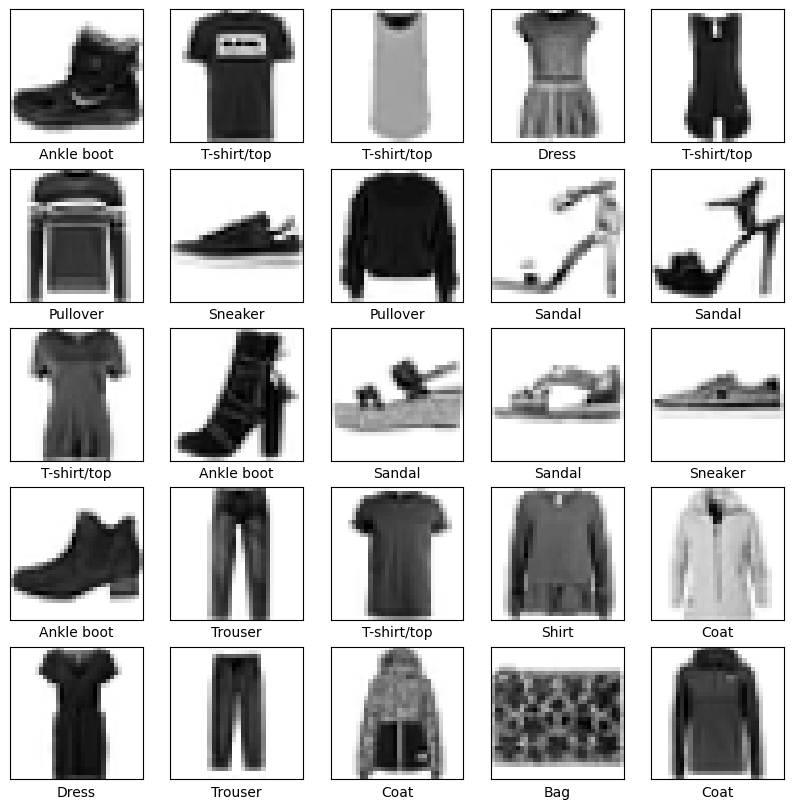

In [2]:
# 2. Visualize một số hình ảnh mẫu
print("\n--- 2. Visualizing Samples ---")
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i].reshape(img_height, img_width), cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()


In [3]:
# 3. Xây dựng mô hình CNN cải tiến (Improved Architecture)
print("\n--- 3. Building CNN Model ---")

model = models.Sequential([
    # Layer 1: Convolution + BatchNorm + Pooling + Dropout
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_height, img_width, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 2: Convolution + BatchNorm + Pooling + Dropout
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 3: Convolution + BatchNorm + Flatten
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    
    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


--- 3. Building CNN Model ---
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 16, 16, 64)        256       
 chNormalization)                                                
                         

In [4]:
# 4. Huấn luyện (Training) với Early Stopping
print("\n--- 4. Training Model ---")

# Early stopping để tránh overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_images, train_labels, epochs=15, 
                    validation_split=0.2, 
                    callbacks=[early_stop],
                    verbose=1)



--- 4. Training Model ---
Epoch 1/15
1500/1500 [==============================] - 15s 9ms/step - loss: 0.3526 - accuracy: 0.8730 - val_loss: 0.2885 - val_accuracy: 0.8960
Epoch 2/15
1500/1500 [==============================] - 14s 9ms/step - loss: 0.2442 - accuracy: 0.9115 - val_loss: 0.3263 - val_accuracy: 0.8735
Epoch 3/15
 275/1500 [====>.........................] - ETA: 11s - loss: 0.2101 - accuracy: 0.9240

1500/1500 [==============================] - 14s 9ms/step - loss: 0.2061 - accuracy: 0.9232 - val_loss: 0.2549 - val_accuracy: 0.9061
Epoch 4/15
1500/1500 [==============================] - 14s 9ms/step - loss: 0.1760 - accuracy: 0.9348 - val_loss: 0.2322 - val_accuracy: 0.9124
Epoch 5/15
1500/1500 [==============================] - 14s 9ms/step - loss: 0.1519 - accuracy: 0.9440 - val_loss: 0.2502 - val_accuracy: 0.9110
Epoch 6/15
1500/1500 [==============================] - 14s 9ms/step - loss: 0.1244 - accuracy: 0.9556 - val_loss: 0.2731 - val_accuracy: 0.9107
Epoch 7/15
1500/1500 [==============================] - 14s 9ms/step - loss: 0.1021 - accuracy: 0.9617 - val_loss: 0.2236 - val_accuracy: 0.9274
Epoch 8/15
1500/1500 [==============================] - 14s 9ms/step - loss: 0.0833 - accuracy: 0.9698 - val_loss: 0.2594 - val_accuracy: 0.9187
Epoch 9/15
1500/1500 [==============================] - 14s 9ms/step - loss: 0.0686 - accuracy: 0.9753 - val_loss: 0.2934 - val_accuracy: 0.9

In [5]:
# 5. Đánh giá trên tập Test (Evaluation)
print("\n--- 5. Evaluating Model ---")
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nTest Accuracy: {test_acc:.4f}')



--- 5. Evaluating Model ---
313/313 - 1s - loss: 0.2397 - accuracy: 0.9243 - 973ms/epoch - 3ms/step

Test Accuracy: 0.9243


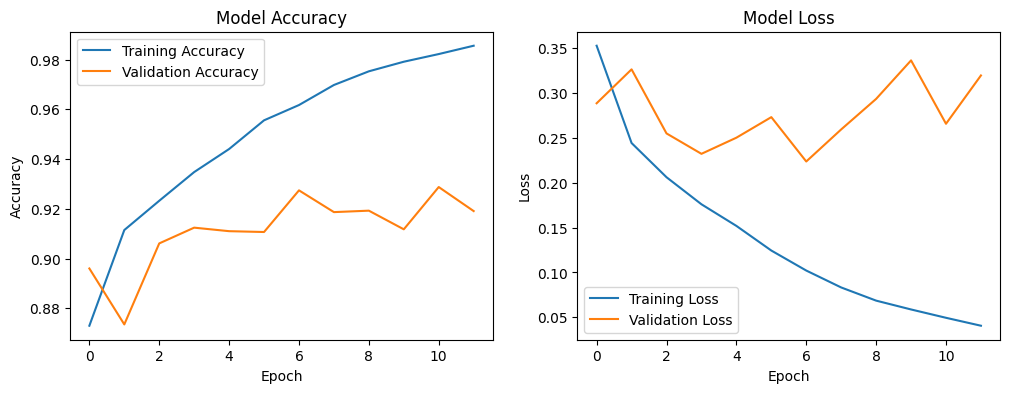

In [6]:
# 6. Visualize kết quả huấn luyện
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



--- 7. Confusion Matrix ---
149/313 [=============>................] - ETA: 0s

313/313 [==============================] - 1s 3ms/step


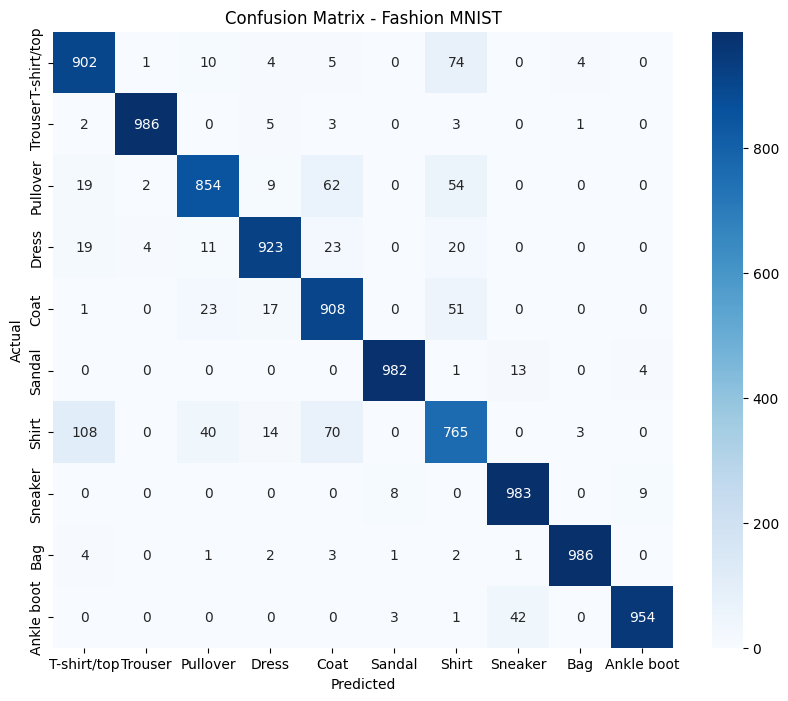

In [7]:
# 7. Dự đoán và hiển thị Confusion Matrix
print("\n--- 7. Confusion Matrix ---")
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fashion MNIST')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

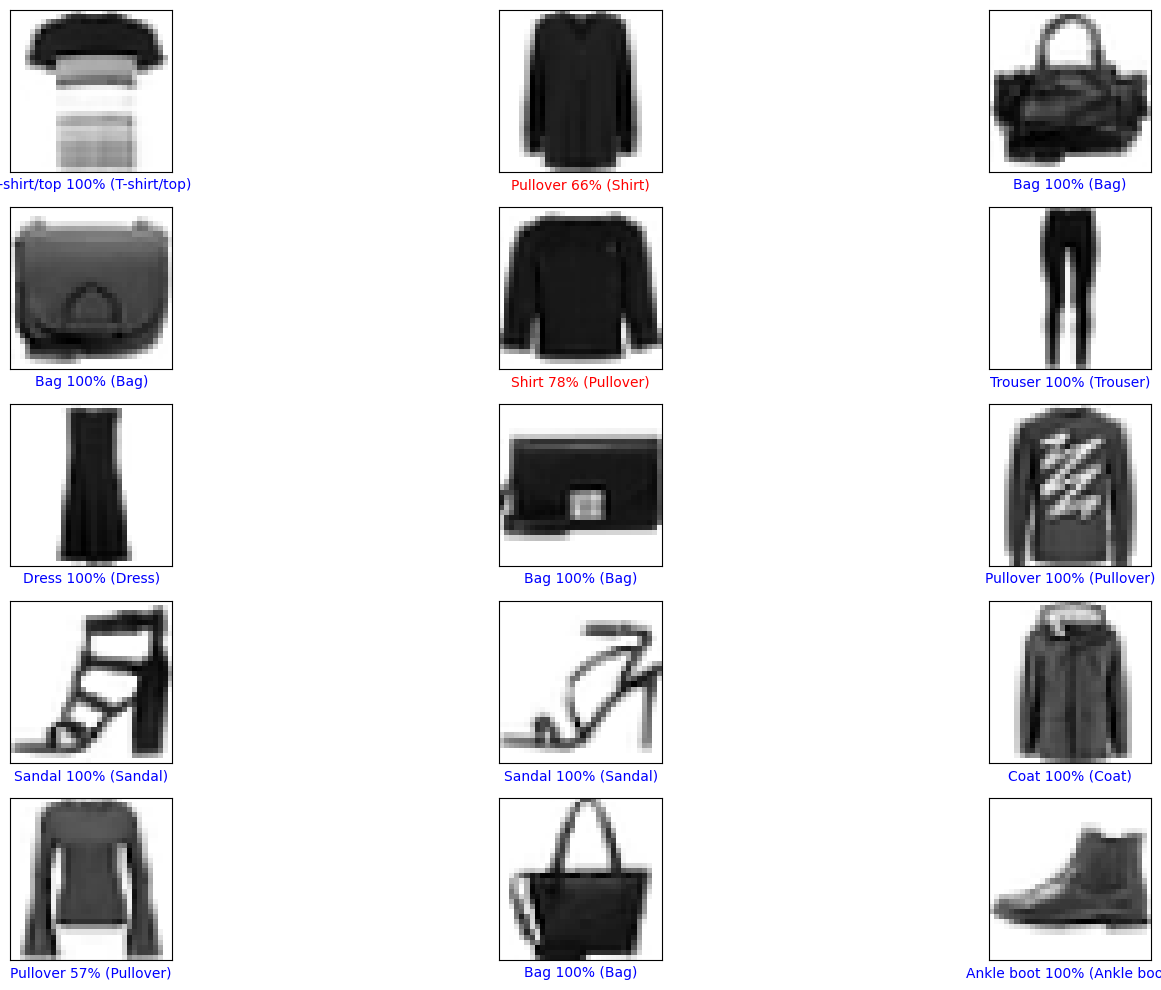

In [8]:
# 8. Hiển thị dự đoán trên các mẫu ngẫu nhiên
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img.reshape(img_height, img_width), cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})", color=color)

plt.figure(figsize=(15, 10))
num_rows, num_cols = 5, 3
for i in range(num_rows * num_cols):
    idx = np.random.randint(0, test_images.shape[0])
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(idx, y_pred[idx], test_labels, test_images)
plt.tight_layout()
plt.show()